# 02. GeN-Foam / fallback + химия для материалов V2

Версия расчета: `materials-v2`. Для каждого материаловедческого сценария сначала требуется собственный внешний ряд GeN-Foam. В текущей среде GeN-Foam установлен и успешно запущен, но отдельных V2-кейсов для `ZrC--W` и `HfC--W` нет; поэтому этот notebook явно включает `python_fallback` и показывает это в outputs.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np

from thesis_modeling.pipeline_v2_export import (
    export_pipeline_v2_artifacts,
    pipeline_v2_specs,
    plot_pipeline_v2_material_window,
    run_pipeline_v2,
)

## Внешние кейсы GeN-Foam и разрешенный fallback

Каждый сценарий V2 в основном режиме обязан иметь собственный каталог GeN-Foam с `thermal_timeseries.csv`. Общий SFR-ряд из первого notebook не подставляется в V2, потому что это была бы физически неверная подмена материалов. Пока отдельных рядов нет, прогон ниже разрешает `python_fallback` явно.

In [2]:
spec_rows = [
    {
        "case": spec.label,
        "fuel": spec.fuel_name,
        "clad": spec.clad_name,
        "pulse_kj_per_m": spec.pulse_energy_j_per_m / 1e3,
        "genfoam_case_path": spec.genfoam_case_path,
    }
    for spec in pipeline_v2_specs()
]
spec_rows

[{'case': '\\(ZrC\\)--W, исследовательский суррогат',
  'fuel': 'ZrC surrogate',
  'clad': 'Tungsten',
  'pulse_kj_per_m': 520.0,
  'genfoam_case_path': '/Users/g.elesin/Desktop/Диплом магистратура/data/genfoam/materials-v2/zrc_w'},
 {'case': '\\(HfC\\)--W, тепловой верхний контрфакт',
  'fuel': 'HfC surrogate',
  'clad': 'Tungsten',
  'pulse_kj_per_m': 480.0,
  'genfoam_case_path': '/Users/g.elesin/Desktop/Диплом магистратура/data/genfoam/materials-v2/hfc_w'}]

## Запуск и первичная сводка

Для каждого сценария сначала пробуется ряд GeN-Foam. Если именно его material-specific ряд отсутствует, запускается одинаковая трехузловая fallback-модель с материалами сценария, а химия переводится в пороговую оценку без Cantera.

In [3]:
runs = run_pipeline_v2(allow_python_fallback=True)
[
    {
        "case": run.report["case"],
        "source": run.result["thermal_source"],
        "chemistry": run.chemistry["method"],
        "uses_cantera": run.chemistry["uses_cantera"],
        "max_steam_k": round(run.report["max_gas_k"]),
        "clad_margin_k": round(run.report["clad_limit_margin_k"]),
        "h2_eq_g_per_m": run.report["peak_h2_g_per_m"],
        "window_before_limits": run.report["threshold_before_material_limits"],
    }
    for run in runs
]

[{'case': '\\(ZrC\\)--W, исследовательский суррогат',
  'source': 'genfoam',
  'chemistry': 'cantera_equilibrium_tp',
  'uses_cantera': True,
  'max_steam_k': 682,
  'clad_margin_k': 3012,
  'h2_eq_g_per_m': 3.5001233622444076e-11,
  'window_before_limits': False},
 {'case': '\\(HfC\\)--W, тепловой верхний контрфакт',
  'source': 'genfoam',
  'chemistry': 'cantera_equilibrium_tp',
  'uses_cantera': True,
  'max_steam_k': 685,
  'clad_margin_k': 3010,
  'h2_eq_g_per_m': 3.5010034409413604e-11,
  'window_before_limits': False}]

## Расчетные детали по каждому материалу

Эта ячейка раскрывает физику сравнения: когда достигается максимум температуры пара, какой запас остается по оболочке, какая доля импульса дошла до паровой прослойки и где находится максимум равновесного водорода.

In [4]:
details = []
for run in runs:
    result = run.result
    chemistry = run.chemistry
    scenario = run.scenario
    time_s = np.asarray(result["time_s"])
    steam_temperature_k = np.asarray(result["water_temperature_k"])
    steam_energy_j_per_m = np.asarray(result["water_energy_j_per_m"])
    pulse_energy_j_per_m = np.asarray(result["pulse_energy_j_per_m"])
    clad_outer_k = np.asarray(result["clad_outer_k"])
    fuel_center_k = np.asarray(result["fuel_center_k"])
    h2_kg_per_m = np.asarray(chemistry["hydrogen_kg_per_m"])

    material_ok = (
        (fuel_center_k < scenario.fuel.melting_temperature_k)
        & (clad_outer_k < scenario.clad.limit_temperature_k)
    )
    threshold_mask = steam_temperature_k >= scenario.chemistry_threshold_k
    eta_steam = np.divide(
        steam_energy_j_per_m,
        pulse_energy_j_per_m,
        out=np.zeros_like(steam_energy_j_per_m),
        where=pulse_energy_j_per_m > 0.0,
    )
    peak_t_i = int(np.argmax(steam_temperature_k))
    peak_h_i = int(np.argmax(h2_kg_per_m))
    first_window = np.flatnonzero(threshold_mask & material_ok)

    details.append(
        {
            "case": run.report["case"],
            "max_steam_k": float(steam_temperature_k[peak_t_i]),
            "time_of_max_steam_s": float(time_s[peak_t_i]),
            "first_window_before_limits_s": float(time_s[first_window[0]]) if first_window.size else np.nan,
            "max_eta_steam_percent": float(np.max(eta_steam) * 100.0),
            "clad_limit_margin_k": float(run.report["clad_limit_margin_k"]),
            "fuel_margin_k": float(run.report["fuel_margin_k"]),
            "peak_h2_g_per_m": float(h2_kg_per_m[peak_h_i] * 1e3),
            "temperature_at_peak_h2_k": float(steam_temperature_k[peak_h_i]),
        }
    )
details

[{'case': '\\(ZrC\\)--W, исследовательский суррогат',
  'max_steam_k': 682.2949,
  'time_of_max_steam_s': 0.58615385,
  'first_window_before_limits_s': nan,
  'max_eta_steam_percent': 0.001147709126505674,
  'clad_limit_margin_k': 3011.9805,
  'fuel_margin_k': 2829.142,
  'peak_h2_g_per_m': 3.5001233622444076e-11,
  'temperature_at_peak_h2_k': 681.4647},
 {'case': '\\(HfC\\)--W, тепловой верхний контрфакт',
  'max_steam_k': 684.6235,
  'time_of_max_steam_s': 0.54769231,
  'first_window_before_limits_s': nan,
  'max_eta_steam_percent': 0.0014457107732570823,
  'clad_limit_margin_k': 3009.5333,
  'fuel_margin_k': 3442.5659,
  'peak_h2_g_per_m': 3.5010034409413604e-11,
  'temperature_at_peak_h2_k': 683.4843}]

## Проверка адекватности V2

Проверки ниже контролируют качество численного результата: источник должен быть либо реальным GeN-Foam, либо явно включенным fallback, время должно возрастать, энергии и массы не должны быть отрицательными, а водород не должен превышать стехиометрический предел.

In [5]:
adequacy = {}
for run in runs:
    result = run.result
    chemistry = run.chemistry
    h2 = np.asarray(chemistry["hydrogen_kg_per_m"])
    h2_max = np.asarray(chemistry["max_hydrogen_kg_per_m"])
    adequacy[run.spec.fuel_name] = {
        "source_is_external_or_explicit_fallback": result["thermal_source"] in {"genfoam", "python_fallback"},
        "chemistry_method_declared": chemistry["method"] in {"cantera_equilibrium_tp", "python_threshold_proxy"},
        "time_monotonic": bool(np.all(np.diff(result["time_s"]) > 0.0)),
        "positive_temperatures": bool(np.all(np.asarray(result["water_temperature_k"]) > 0.0)),
        "nonnegative_energy": bool(np.all(np.asarray(result["water_energy_j_per_m"]) >= 0.0)),
        "energy_balance_ok": bool(run.validation["checks"]["energy_balance_ok"]),
        "h2_not_above_stoich": bool(np.all(h2 <= h2_max + 1e-15)),
        "finite_report_values": bool(np.isfinite(run.report["max_gas_k"]) and np.isfinite(run.report["clad_limit_margin_k"])),
    }

assert all(all(checks.values()) for checks in adequacy.values()), adequacy
adequacy

{'ZrC surrogate': {'source_is_external_or_explicit_fallback': True,
  'chemistry_method_declared': True,
  'time_monotonic': True,
  'positive_temperatures': True,
  'nonnegative_energy': True,
  'energy_balance_ok': True,
  'h2_not_above_stoich': True,
  'finite_report_values': True},
 'HfC surrogate': {'source_is_external_or_explicit_fallback': True,
  'chemistry_method_declared': True,
  'time_monotonic': True,
  'positive_temperatures': True,
  'nonnegative_energy': True,
  'energy_balance_ok': True,
  'h2_not_above_stoich': True,
  'finite_report_values': True}}

## Сравнение сценариев

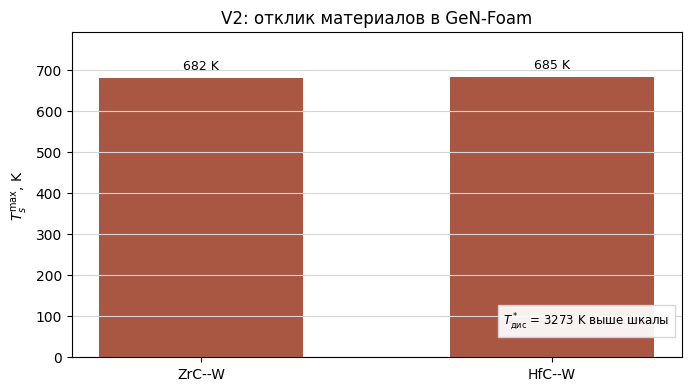

In [6]:
fig = plot_pipeline_v2_material_window(runs)
plt.show()

In [7]:
ranking = sorted(
    details,
    key=lambda row: (row["max_steam_k"], row["peak_h2_g_per_m"]),
    reverse=True,
)
ranking

[{'case': '\\(HfC\\)--W, тепловой верхний контрфакт',
  'max_steam_k': 684.6235,
  'time_of_max_steam_s': 0.54769231,
  'first_window_before_limits_s': nan,
  'max_eta_steam_percent': 0.0014457107732570823,
  'clad_limit_margin_k': 3009.5333,
  'fuel_margin_k': 3442.5659,
  'peak_h2_g_per_m': 3.5010034409413604e-11,
  'temperature_at_peak_h2_k': 683.4843},
 {'case': '\\(ZrC\\)--W, исследовательский суррогат',
  'max_steam_k': 682.2949,
  'time_of_max_steam_s': 0.58615385,
  'first_window_before_limits_s': nan,
  'max_eta_steam_percent': 0.001147709126505674,
  'clad_limit_margin_k': 3011.9805,
  'fuel_margin_k': 2829.142,
  'peak_h2_g_per_m': 3.5001233622444076e-11,
  'temperature_at_peak_h2_k': 681.4647}]

## Синхронизация с LaTeX

При тестовом запуске можно поставить `SKIP_PIPELINE_EXPORT=1`, чтобы не перезаписывать рисунки. Для V2 fallback передается явно, потому что отдельных GeN-Foam рядов для этих материалов пока нет.

In [8]:
if os.environ.get("SKIP_PIPELINE_EXPORT") != "1":
    export_pipeline_v2_artifacts(ROOT / "figures", allow_python_fallback=True)